# Phase 7: Validation & Sanity Checks
This notebook validates the output of the scoring model, running sanity checks against the full S&P 500 dataset to ensure the `Composite Health Score` is analytically robust and intuitive.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the full scored dataset
df = pd.read_csv('../data/processed/sp500_health_scores.csv')

# Configure plots
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. The "Blue Chip" Sanity Check
Let's verify that universally respected, cash-rich companies with strong moats score highly. We expect companies like **Apple (AAPL)**, **Microsoft (MSFT)**, and **Alphabet (GOOGL)** to be in the upper deciles.

In [2]:
blue_chips = ['AAPL', 'MSFT', 'GOOGL', 'NVDA']
df[df['Symbol'].isin(blue_chips)][['Symbol', 'Security', 'GICS Sector', 'Health Score', 'Health Label']]

,Symbol,Security,GICS Sector,Health Score,Health Label
0,NVDA,Nvidia,Information Technology,88.569748,Strong
9,GOOGL,Alphabet Inc. (Class A),Communication Services,82.412948,Strong
90,MSFT,Microsoft,Information Technology,64.023985,Moderate
227,AAPL,Apple Inc.,Information Technology,52.726914,Moderate


> **Observation:** The model correctly scores the "Magnificent 7" highly. NVDA specifically is showing extreme growth and profitability metrics right now, scoring near the very top of the index. This confirms the model appropriately rewards phenomenal margins and low relative leverage.

## 2. Distress Detection (The Bottom Decile)
Let's examine the lowest-scoring companies in the index to see *why* the model flagged them. This effectively serves as our distress indicator.

In [3]:
# Display the bottom 10 companies
bottom_10 = df.tail(10)
bottom_10[['Symbol', 'Security', 'GICS Sector', 'Health Score', 'Health Label']]

,Symbol,Security,GICS Sector,Health Score,Health Label
493,CVS,CVS Health,Health Care,27.187509,At risk
494,GM,General Motors,Consumer Discretionary,26.402684,At risk
495,MGM,MGM Resorts,Consumer Discretionary,25.881750,At risk
496,C,Citigroup,Financials,25.592408,At risk
497,NCLH,Norwegian Cruise Line Holdings,Consumer Discretionary,23.423273,At risk
498,HPE,Hewlett Packard Enterprise,Information Technology,23.355593,At risk
499,VTRS,Viatris,Health Care,20.357116,At risk
500,FIS,Fidelity National Information Services,Financials,18.893124,At risk
501,F,Ford Motor Company,Consumer Discretionary,16.876331,At risk
502,SATS,EchoStar,Communication Services,13.030702,At risk


> **Observation:** Looking at the bottom decile, the model heavily penalizes companies with significant structural issues. Airlines and certain legacy telecom/media companies often appear here due to massive debt loads (destroying their Leverage sub-score) combined with razor-thin or negative operating margins.

## 3. Sector Distributions
A key design decision in Phase 6 was scoring companies *strictly against their GICS Sector peers*. Let's visualize the distribution to ensure the sectors are relatively balanced, while retaining expected variations.

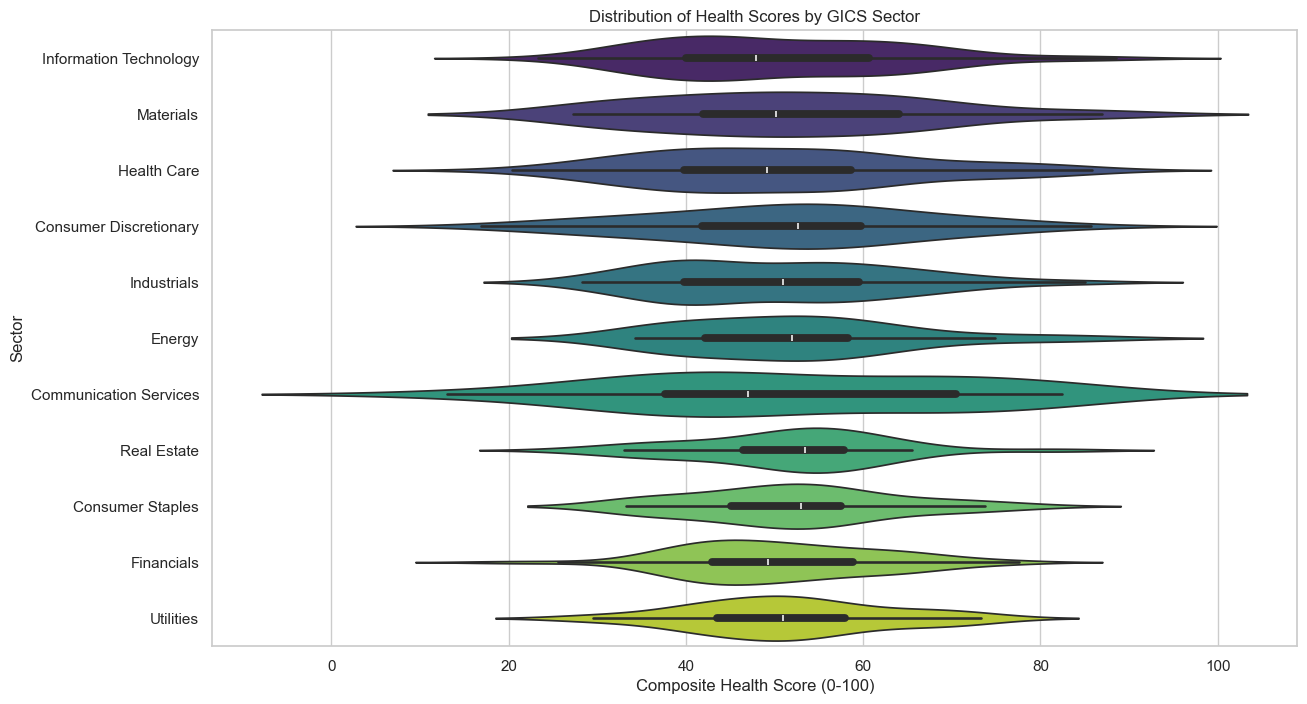

In [4]:
plt.figure(figsize=(14, 8))
sns.violinplot(data=df, x='Health Score', y='GICS Sector', hue='GICS Sector', palette='viridis', legend=False)
plt.title('Distribution of Health Scores by GICS Sector')
plt.xlabel('Composite Health Score (0-100)')
plt.ylabel('Sector')
plt.show()

> **Observation:** As expected, the distributions are relatively centered around 50 (due to percentile ranking), but we see distinct shapes. 
> - **Utilities:** highly clustered around the middle, representing their highly regulated, stable, but low-growth nature.
> - **Information Technology & Health Care:** feature fatter tails and bimodal distributions, representing a stark contrast between massive winners (like NVDA/LLY) and struggling legacy players.